# Building a Chatbot Agent in LangGraph: Practice Exercise

Build a calculator assistant chatbot using LangGraph that can perform arithmetic operations. You will define state with message handling, create a chatbot node, add tool support, and wire up the graph with conditional edges.

**What you'll implement:**
- Define a State class using TypedDict with message annotation
- Create a chatbot node function that invokes the LLM
- Build and compile a StateGraph with nodes, edges, and conditional routing

**Estimated time:** 10-15 minutes

## Setup

Run this cell to import all required libraries and configure the environment.

In [ ]:
%pip install -qU langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 12.9 MB/s eta 0:00:00


In [ ]:
# Setup - run this cell first

import os
from typing import Annotated
from typing_extensions import TypedDict


from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Load environment variables
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ


if not IN_COLAB:
  from dotenv import load_dotenv
  load_dotenv()
  # Verify OpenAI API key is set
  if not os.getenv("OPENAI_API_KEY"):
    ("WARNING: OPENAI_API_KEY environment variable not set!")
  else:
    OPEN_AI_API_KEY=os.getenv("OPENAI_API_KEY")
    print("OpenAI API key found. Ready to proceed!")
else:
  from google.colab import userdata
  OPEN_AI_API_KEY=userdata.get('OPEN_AI_API_KEY')

## Context

You are building a calculator assistant chatbot that can perform basic arithmetic operations. The chatbot should:

1. Respond to general conversation
2. Use calculator tools when the user asks for math operations
3. Return to the chatbot after tool execution to process results

**Tools provided:** Two calculator tools are defined below - `add_numbers` and `multiply_numbers`.

**Graph structure:**
- Entry point: `assistant` node (the chatbot)
- Conditional routing: If the LLM wants to call a tool, route to `tools` node; otherwise end
- After tools execute, return to `assistant` to process the result

**Expected behavior:**
- Query: "What is 5 + 3?" -> Uses add_numbers tool -> Returns "8" (or similar)
- Query: "Hello!" -> Responds conversationally without using tools

## Provided Tools

These tools are already implemented for you.

In [ ]:
# Calculator tools - provided for you

@tool
def add_numbers(a: float, b: float) -> float:
    """Add two numbers together and return the result."""
    return a + b

@tool
def multiply_numbers(a: float, b: float) -> float:
    """Multiply two numbers together and return the result."""
    return a * b

# List of tools for the agent
tools = [add_numbers, multiply_numbers]

print(f"Tools available: {[t.name for t in tools]}")

Tools available: ['add_numbers', 'multiply_numbers']


## Provided LLM Setup

The LLM is configured and bound to the tools for you.

In [ ]:
# LLM setup - provided for you

llm = ChatOpenAI(model="gpt-4o",api_key=OPEN_AI_API_KEY)
llm_with_tools = llm.bind_tools(tools)

print("LLM configured with tools!")

LLM configured with tools!


## Step 1: Define the State

Create a State class that holds the conversation messages. Use `Annotated` with `add_messages` to enable automatic message list management.

In [ ]:
class AgentState(TypedDict):
    """
    State for the calculator chatbot.

    Fields:
        messages: List of conversation messages, annotated with add_messages
                  for automatic message handling (appending new messages)

    Hint: Use Annotated[list, add_messages] for the messages field
    """
    # TODO: Define the messages field with proper annotation
    messages: Annotated[list, add_messages]

## Step 2: Create the Chatbot Node Function

Create a node function that takes the current state, invokes the LLM with the messages, and returns the response.

In [ ]:
def assistant(state: AgentState) -> dict:
    """
    Chatbot node that processes messages and generates responses.

    Args:
        state: Current agent state containing the messages list

    Returns:
        Dictionary with 'messages' key containing the LLM response
        wrapped in a list (the add_messages annotation will handle appending)

    Hint: Invoke llm_with_tools with state["messages"] and return
          the result wrapped in a list under the "messages" key
    """
    # TODO: Invoke the LLM and return the response
    return {"messages":[llm_with_tools.invoke(state["messages"])] }

## Step 3: Build and Compile the Graph

Create a function that builds the complete chatbot graph with nodes, edges, and conditional routing.

In [ ]:
def build_calculator_chatbot():
    """
    Build and compile the calculator chatbot graph.

    Graph structure:
    - Entry point: "assistant" node
    - Conditional edge from "assistant":
        - If tool call requested -> route to "tools" node
        - Otherwise -> END
    - Edge from "tools" -> back to "assistant"

    Returns:
        Compiled graph ready for invocation

    Hints:
    - Use StateGraph(AgentState) to create the builder
    - Use ToolNode(tools) to create the tools node
    - Use add_conditional_edges with tools_condition for routing
    - Use set_entry_point to set "assistant" as the starting node
    """
    # TODO 1: Create a StateGraph with AgentState
    builder = StateGraph(AgentState)
    # TODO 2: Add the "assistant" node (using the assistant function)
    builder.add_node("assistant", assistant)
    # TODO 3: Create a ToolNode and add it as the "tools" node
    tool_node = ToolNode(tools)
    builder.add_node("tools", tool_node)
    # TODO 4: Add conditional edges from "assistant" using tools_condition
    builder.add_conditional_edges("assistant", tools_condition)
    # TODO 5: Add an edge from "tools" back to "assistant"
    builder.add_edge("tools","assistant")
    # TODO 6: Set the entry point to "assistant"
    builder.set_entry_point("assistant")
    # TODO 7: Compile and return the graph
    graph = builder.compile()
    return graph

## Run Your Implementation

Test your chatbot with various queries.

In [ ]:
# Build the chatbot
chatbot = build_calculator_chatbot()
print("Chatbot built successfully!")

Chatbot built successfully!


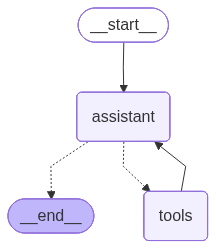

In [ ]:
# Visualize the graph (optional)
from IPython.display import display, Image

try:
    display(Image(chatbot.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization requires additional dependencies")

In [ ]:
# Test 1: Simple greeting (should NOT use tools)
print("Test 1: Simple greeting")
print("=" * 50)

result = chatbot.invoke({"messages": [("user", "Hello! What can you help me with?")]})

for msg in result["messages"]:
    if hasattr(msg, 'content') and msg.content:
        role = getattr(msg, 'type', 'unknown')
        print(f"{role}: {msg.content}")
print()

Test 1: Simple greeting
human: Hello! What can you help me with?
ai: Hello! I can assist you with a variety of tasks, including:

1. Performing mathematical calculations and operations.
2. Providing explanations on a wide range of topics.
3. Helping with language translations and grammar.
4. Offering suggestions or recommendations, such as for books, movies, or music.
5. Answering trivia and general knowledge questions.
6. Assisting with coding and debugging in various programming languages.

If you have a specific task or question, feel free to ask!



In [ ]:
# Test 2: Addition query (should use add_numbers tool)
print("Test 2: Addition query")
print("=" * 50)

result = chatbot.invoke({"messages": [("user", "What is 15 + 27?")]})

for msg in result["messages"]:
    role = getattr(msg, 'type', 'unknown')
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"{role}: [Tool call: {msg.tool_calls[0]['name']}({msg.tool_calls[0]['args']})]")
    elif hasattr(msg, 'content') and msg.content:
        print(f"{role}: {msg.content}")
print()

Test 2: Addition query
human: What is 15 + 27?
ai: [Tool call: add_numbers({'a': 15, 'b': 27})]
tool: 42.0
ai: 15 + 27 equals 42.



In [ ]:
# Test 3: Multiplication query (should use multiply_numbers tool)
print("Test 3: Multiplication query")
print("=" * 50)

result = chatbot.invoke({"messages": [("user", "Calculate 8 times 6 for me.")]})

for msg in result["messages"]:
    role = getattr(msg, 'type', 'unknown')
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"{role}: [Tool call: {msg.tool_calls[0]['name']}({msg.tool_calls[0]['args']})]")
    elif hasattr(msg, 'content') and msg.content:
        print(f"{role}: {msg.content}")
print()

Test 3: Multiplication query
human: Calculate 8 times 6 for me.
ai: [Tool call: multiply_numbers({'a': 8, 'b': 6})]
tool: 48.0
ai: The result of \(8 \times 6\) is 48.

